In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../results/dvs128_snn_01_to_09_batch8_3seeds_count_beta05.txt")
df.head()

,representation,coding,train_size,val_size,seed,batch_size,val_rate_acc,val_temp_acc,test_rate_acc,test_temp_acc,epoch,batch_size.1,loss,beta
0,n_bins,count,0.1,0.1,42.0,8.0,0.0,0.0,0.5152,0.4773,11.0,8.0,count,0.5
1,n_bins,count,0.3,0.1,42.0,8.0,0.0,0.0,0.5871,0.5303,9.0,8.0,count,0.5
2,n_bins,count,0.5,0.1,42.0,8.0,0.0,0.0,0.8068,0.6591,23.0,8.0,count,0.5
3,n_bins,count,0.7,0.1,42.0,8.0,0.0,0.0,0.8068,0.6136,29.0,8.0,count,0.5
4,n_bins,count,0.9,0.1,42.0,8.0,0.0,0.0,0.8371,0.7045,13.0,8.0,count,0.5


In [4]:
df = df.drop(['val_rate_acc', 'val_temp_acc', 'batch_size.1', 'coding'], axis=1)
df['epoch'] = df['epoch'] + 1
df.head()

,representation,train_size,val_size,seed,batch_size,test_rate_acc,test_temp_acc,epoch,loss,beta
0,n_bins,0.1,0.1,42.0,8.0,0.5152,0.4773,12.0,count,0.5
1,n_bins,0.3,0.1,42.0,8.0,0.5871,0.5303,10.0,count,0.5
2,n_bins,0.5,0.1,42.0,8.0,0.8068,0.6591,24.0,count,0.5
3,n_bins,0.7,0.1,42.0,8.0,0.8068,0.6136,30.0,count,0.5
4,n_bins,0.9,0.1,42.0,8.0,0.8371,0.7045,14.0,count,0.5


In [6]:
grouped_data = df.groupby(['train_size', 'representation']).agg({
    'test_rate_acc': 'mean',
    'test_temp_acc': 'mean',
    'epoch': 'mean'
}).reset_index()
grouped_data.head()

,train_size,representation,test_rate_acc,test_temp_acc,epoch
0,0.1,binary,0.090900,0.0909,11.333333
1,0.1,n_bins,0.532867,0.4836,11.333333
2,0.1,spike_count,0.390133,0.3851,11.333333
3,0.1,time_window,0.285367,0.2803,11.333333
4,0.1,timesurface,0.090900,0.0909,11.333333


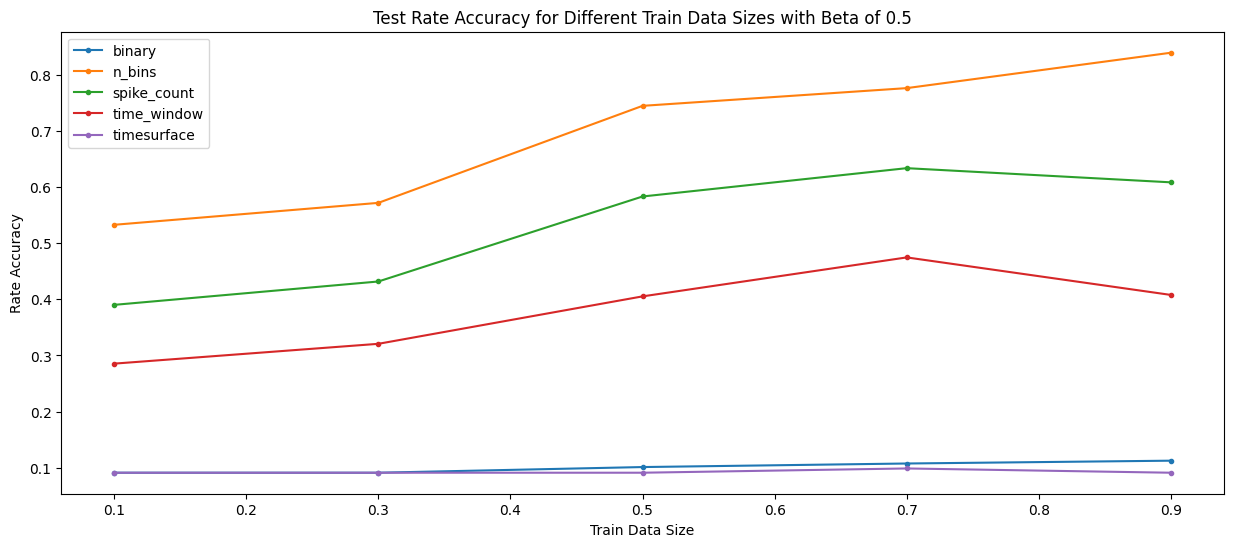

In [7]:
sns.reset_orig()

fig, ax = plt.subplots(figsize=(15, 6))

for representation in grouped_data['representation'].unique():
    rep_data = grouped_data[grouped_data['representation'] == representation]
    plt.plot(rep_data['train_size'], rep_data['test_rate_acc'], label=f'{representation}', marker='.')

plt.xlabel('Train Data Size')
plt.ylabel('Rate Accuracy')
plt.title('Test Rate Accuracy for Different Train Data Sizes with Beta of 0.5')
plt.legend()
plt.show()

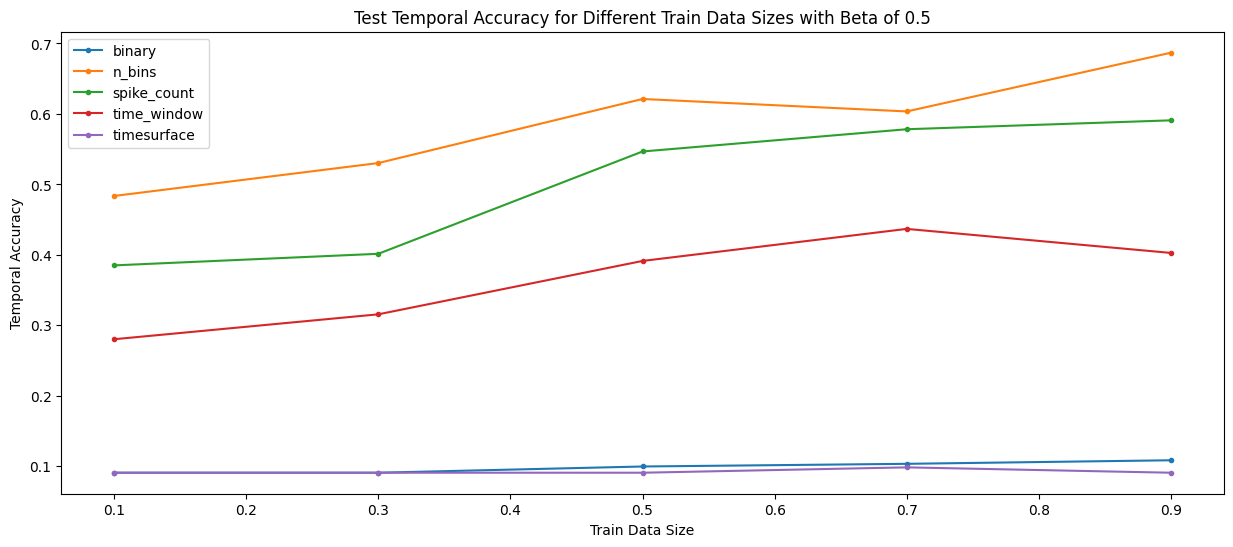

In [8]:
sns.reset_orig()

fig, ax = plt.subplots(figsize=(15, 6))

for representation in grouped_data['representation'].unique():
    rep_data = grouped_data[grouped_data['representation'] == representation]
    plt.plot(rep_data['train_size'], rep_data['test_temp_acc'], label=f'{representation}', marker='.')

plt.xlabel('Train Data Size')
plt.ylabel('Temporal Accuracy')
plt.title('Test Temporal Accuracy for Different Train Data Sizes with Beta of 0.5')
plt.legend()
plt.show()

In [10]:
df = pd.read_csv('../results/dvs128_snn_01_to_09_batch8_3seeds_count_beta09.txt')

In [11]:
df = df.drop(['val_rate_acc', 'val_temp_acc'], axis=1)
df['num_epochs'] = df['num_epochs'] + 1

In [12]:
df.head()

,representation,loss,train_size,val_size,random_seed,batch_size,test_rate_acc,test_temp_acc,num_epochs,batch_size.1,loss.1,beta
0,n_bins,count,0.1,0.1,42,8,0.5152,0.4773,12,8,count,0.9
1,n_bins,count,0.3,0.1,42,8,0.5871,0.5303,10,8,count,0.9
2,n_bins,count,0.5,0.1,42,8,0.8068,0.6591,24,8,count,0.9
3,n_bins,count,0.7,0.1,42,8,0.8068,0.6136,30,8,count,0.9
4,n_bins,count,0.9,0.1,42,8,0.8371,0.7045,14,8,count,0.9


In [13]:
df = df.drop(['batch_size.1', 'loss.1', 'beta'], axis=1)
df.head()

,representation,loss,train_size,val_size,random_seed,batch_size,test_rate_acc,test_temp_acc,num_epochs
0,n_bins,count,0.1,0.1,42,8,0.5152,0.4773,12
1,n_bins,count,0.3,0.1,42,8,0.5871,0.5303,10
2,n_bins,count,0.5,0.1,42,8,0.8068,0.6591,24
3,n_bins,count,0.7,0.1,42,8,0.8068,0.6136,30
4,n_bins,count,0.9,0.1,42,8,0.8371,0.7045,14


In [15]:
grouped_data = df.groupby(['train_size', 'representation']).agg({
    'test_rate_acc': 'mean',
    'test_temp_acc': 'mean',
    'num_epochs': 'mean'
}).reset_index()
grouped_data = grouped_data.round(2)
grouped_data.head()

,train_size,representation,test_rate_acc,test_temp_acc,num_epochs
0,0.1,binary,0.09,0.09,11.33
1,0.1,n_bins,0.53,0.48,11.33
2,0.1,spike_count,0.39,0.39,11.33
3,0.1,time_window,0.29,0.28,11.33
4,0.1,timesurface,0.09,0.09,11.00


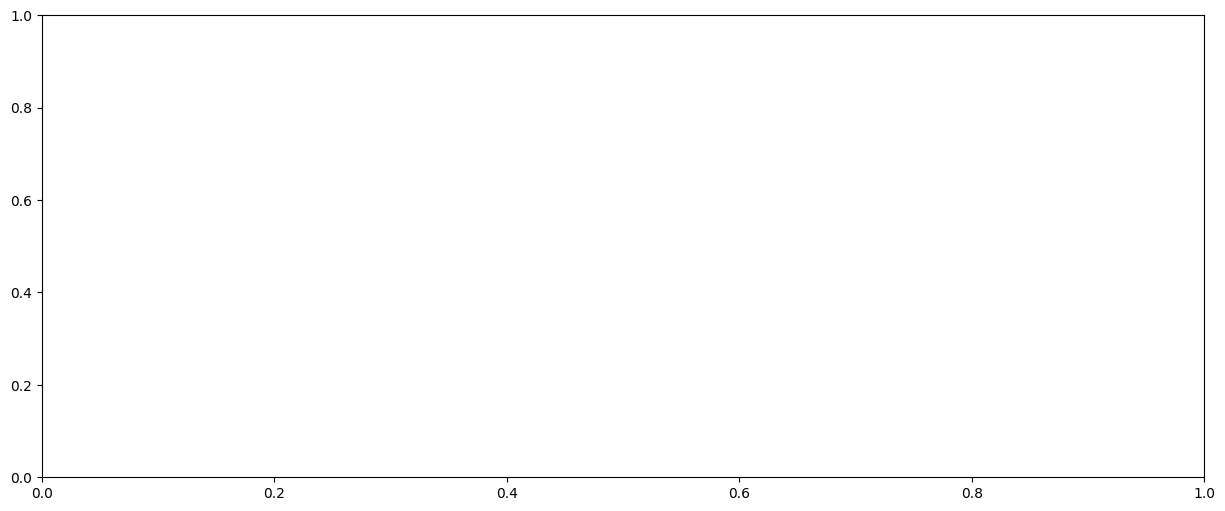

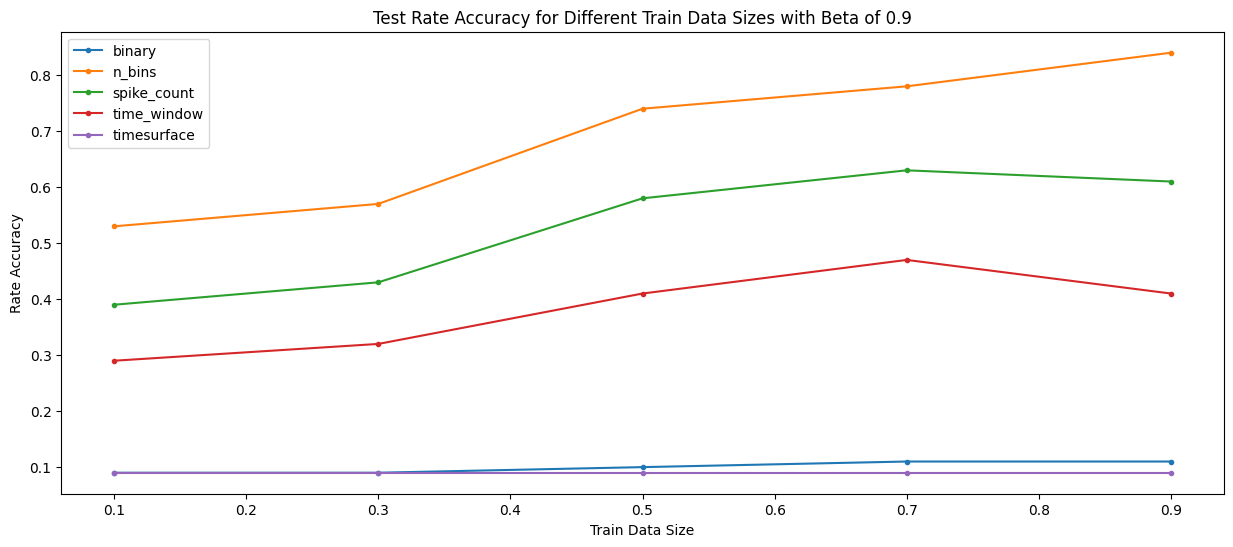

In [17]:
sns.reset_orig()

fig, ax = plt.subplots(figsize=(15, 6))

for representation in grouped_data['representation'].unique():
    rep_data = grouped_data[grouped_data['representation'] == representation]
    plt.plot(rep_data['train_size'], rep_data['test_rate_acc'], label=f'{representation}', marker='.')

plt.xlabel('Train Data Size')
plt.ylabel('Rate Accuracy')
plt.title('Test Rate Accuracy for Different Train Data Sizes with Beta of 0.9')
plt.legend()
plt.show()

In [9]:
df = pd.read_csv('../results/dvs128_snn_09_batch8_count_beta05.txt')
df.head()

,representation,loss,train_size,val_size,random_seed,batch_size,val_rate_acc,val_temp_acc,test_rate_acc,test_temp_acc,num_epochs,batch_size.1,loss.1,beta
0,n_bins,count,0.9,0.1,42,8,0,0,0.8371,0.7045,13.0,8.0,count,0.5
1,binary,count,0.9,0.1,42,8,0,0,0.0909,0.0909,13.0,8.0,count,0.5
2,time_window,count,0.9,0.1,42,8,0,0,0.3902,0.3598,13.0,8.0,count,0.5
3,spike_count,count,0.9,0.1,42,8,0,0,0.6098,0.5568,13.0,8.0,count,0.5
4,timesurface,count,0.9,0.1,42,8,0,0,0.0909,0.0909,13.0,8.0,count,0.5


In [3]:
df = df.drop(['val_rate_acc', 'val_temp_acc'], axis=1)
df['num_epochs'] = df['num_epochs'] + 1
df = df.drop(['batch_size.1', 'loss.1', 'beta'], axis=1)
df.head()

,representation,loss,train_size,val_size,random_seed,batch_size,test_rate_acc,test_temp_acc,num_epochs
0,n_bins,count,0.9,0.1,42,8,0.8371,0.7045,14.0
1,binary,count,0.9,0.1,42,8,0.0909,0.0909,14.0
2,time_window,count,0.9,0.1,42,8,0.3902,0.3598,14.0
3,spike_count,count,0.9,0.1,42,8,0.6098,0.5568,14.0
4,timesurface,count,0.9,0.1,42,8,0.0909,0.0909,14.0


C:\Users\osvat\AppData\Local\Temp\ipykernel_17120\3529193584.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\osvat\AppData\Local\Temp\ipykernel_17120\3529193584.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


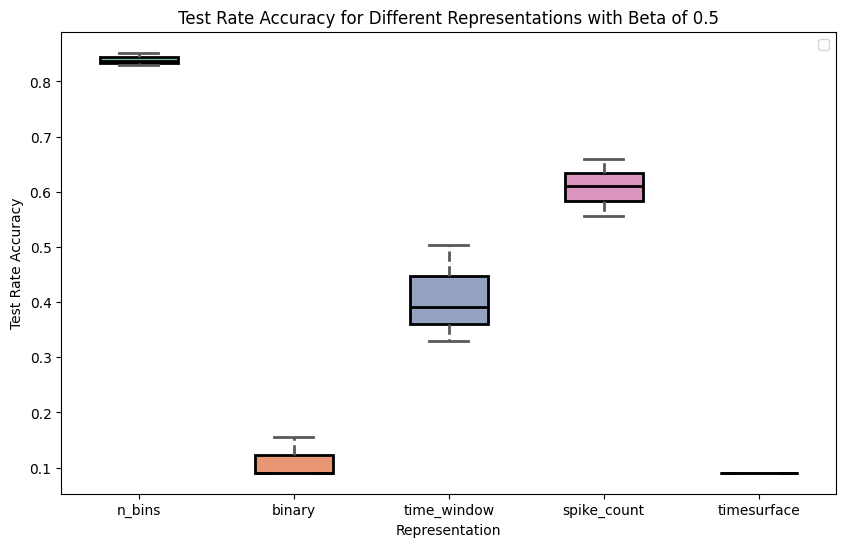

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df, 
    x="representation", 
    y="test_rate_acc",
    palette="Set2",  # Different colors for each box
    width=0.5,       # Adjust box width
    linewidth=2,     # Border thickness
    flierprops={
        "marker": "o",          # Use points for outliers
        "markerfacecolor": "red",  # Outlier color
        "markersize": 8,        # Outlier size
    },
    whiskerprops={"linestyle": "--"},  # Dashed whiskers
    boxprops={"edgecolor": "black"},  # Box border color
    medianprops={"color": "black"},   # Median line color
)

ax.set_xlabel('Representation')
ax.set_ylabel('Test Rate Accuracy')
ax.set_title('Test Rate Accuracy for Different Representations with Beta of 0.5')
ax.legend()
plt.show()

In [5]:
grouped_data = df.groupby(['representation']).agg({
    'test_rate_acc': ['mean', 'std'],
    'test_temp_acc': ['mean', 'std'],
    'num_epochs': 'mean'
}).reset_index()
grouped_data.head()

representation test_rate_acc           test_temp_acc           num_epochs
                          mean       std          mean       std       mean
0         binary      0.112367  0.037181      0.108567  0.030600       18.0
1         n_bins      0.839633  0.011609      0.686833  0.062502       18.0
2    spike_count      0.608567  0.051161      0.590900  0.038467       18.0
3    time_window      0.407833  0.088478      0.402767  0.067945       18.0
4    timesurface      0.090900  0.000000      0.090900  0.000000       18.0

In [6]:
grouped_data = grouped_data.round(2)
grouped_data.head()

representation test_rate_acc       test_temp_acc       num_epochs
                          mean   std          mean   std       mean
0         binary          0.11  0.04          0.11  0.03       18.0
1         n_bins          0.84  0.01          0.69  0.06       18.0
2    spike_count          0.61  0.05          0.59  0.04       18.0
3    time_window          0.41  0.09          0.40  0.07       18.0
4    timesurface          0.09  0.00          0.09  0.00       18.0

In [4]:
grouped_data.to_csv("dvs128_snn_count_beta05_grouped.csv")

NameError: name 'grouped_data' is not defined

In [5]:
df = pd.read_csv('../results/dvs128_snn_09_batch8_count_beta09.txt')
df.head()

,representation,loss,train_size,val_size,random_seed,batch_size,val_rate_acc,val_temp_acc,test_rate_acc,test_temp_acc,num_epochs,batch_size.1,loss.1,beta
0,n_bins,count,0.9,0.1,42,8,0,0,0.8371,0.7045,13.0,8.0,count,0.9
1,binary,count,0.9,0.1,42,8,0,0,0.0909,0.0909,13.0,8.0,count,0.9
2,time_window,count,0.9,0.1,42,8,0,0,0.3902,0.3598,13.0,8.0,count,0.9
3,spike_count,count,0.9,0.1,42,8,0,0,0.6098,0.5568,13.0,8.0,count,0.9
4,timesurface,count,0.9,0.1,42,8,0,0,0.0909,0.0909,13.0,8.0,count,0.9


In [6]:
df = df.drop(['val_rate_acc', 'val_temp_acc'], axis=1)
df['num_epochs'] = df['num_epochs'] + 1
df = df.drop(['batch_size.1', 'loss.1', 'beta'], axis=1)
df.head()

,representation,loss,train_size,val_size,random_seed,batch_size,test_rate_acc,test_temp_acc,num_epochs
0,n_bins,count,0.9,0.1,42,8,0.8371,0.7045,14.0
1,binary,count,0.9,0.1,42,8,0.0909,0.0909,14.0
2,time_window,count,0.9,0.1,42,8,0.3902,0.3598,14.0
3,spike_count,count,0.9,0.1,42,8,0.6098,0.5568,14.0
4,timesurface,count,0.9,0.1,42,8,0.0909,0.0909,14.0


C:\Users\osvat\AppData\Local\Temp\ipykernel_3600\2999479027.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\osvat\AppData\Local\Temp\ipykernel_3600\2999479027.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


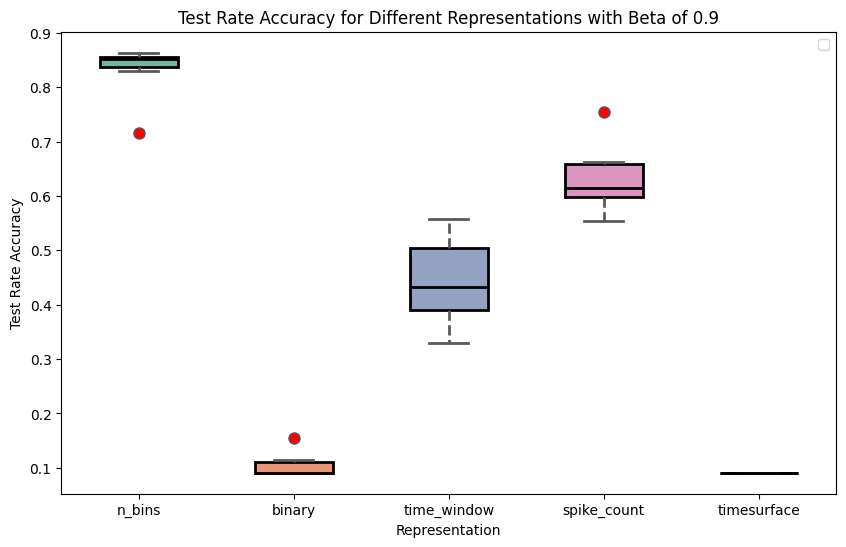

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df, 
    x="representation", 
    y="test_rate_acc",
    palette="Set2",  # Different colors for each box
    width=0.5,       # Adjust box width
    linewidth=2,     # Border thickness
    flierprops={
        "marker": "o",          # Use points for outliers
        "markerfacecolor": "red",  # Outlier color
        "markersize": 8,        # Outlier size
    },
    whiskerprops={"linestyle": "--"},  # Dashed whiskers
    boxprops={"edgecolor": "black"},  # Box border color
    medianprops={"color": "black"},   # Median line color
)

ax.set_xlabel('Representation')
ax.set_ylabel('Test Rate Accuracy')
ax.set_title('Test Rate Accuracy for Different Representations with Beta of 0.9')
ax.legend()
plt.show()

In [13]:
grouped_data = df.groupby(['representation']).agg({
    'test_rate_acc': ['mean', 'std'],
    'test_temp_acc': ['mean', 'std'],
    'num_epochs': 'mean'
}).reset_index()
grouped_data = grouped_data.round(2)
grouped_data.head()

representation test_rate_acc       test_temp_acc       num_epochs
                          mean   std          mean   std       mean
0         binary          0.10  0.02          0.10  0.02      18.44
1         n_bins          0.83  0.05          0.69  0.05      18.44
2    spike_count          0.63  0.06          0.59  0.04      18.44
3    time_window          0.44  0.07          0.42  0.06      18.44
4    timesurface          0.09  0.00          0.09  0.00      17.50

In [14]:
grouped_data.to_csv("dvs128_snn_count_beta09_grouped.csv")